# License Plate Detection with YOLO11

## Practical Work — TP Final: Computer Vision

---

Fine-tune YOLO11 to detect **license plates** in **vehicle images**, running entirely in a local Python environment.

### Pipeline
```
Roboflow Dataset      YOLO11 Training       Deploy
(Plate images)    ->  (Fine-tuning)      -> (API)
```

## Prerequisites

1. Install dependencies: `uv sync`
2. Create a `.env` file in the project root with the following keys:
   ```
   ROBOFLOW_API_KEY=your_roboflow_key
   WORKSPACE_NAME=your_workspace_name
   PROJECT_NAME=your_project_name
   ```
   - Roboflow key: https://app.roboflow.com/settings/api

---
## Section 0: Environment Setup

In [1]:
!nvidia-smi

Sun Jun  7 14:06:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 573.91                 Driver Version: 573.91         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A4000 Laptop GPU  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   53C    P8             16W /  100W |    2125MiB /   8192MiB |     44%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%matplotlib inline
import os
import random
from pathlib import Path

import numpy as np
import torch
import ultralytics
from IPython.display import Image as IPyImage, display

ROOT = Path.cwd()
DATASETS_DIR = ROOT / "datasets"
RUNS_DIR = ROOT / "runs"
MODELS_DIR = ROOT / "models"
MODEL_NAME = "yolo11n.pt"

DATASETS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)
RUNS_DIR.mkdir(exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Project root : {ROOT}")
print(f"PyTorch      : {torch.__version__}")
print(f"Device       : {device}")
ultralytics.checks()

In [3]:
torch.cuda.is_available()

True

In [4]:
from dotenv import load_dotenv

load_dotenv()

ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY")
WORKSPACE_NAME = os.getenv("WORKSPACE_NAME")
PROJECT_NAME = os.getenv("PROJECT_NAME")

missing = [
    k
    for k, v in {
        "ROBOFLOW_API_KEY": ROBOFLOW_API_KEY,
    }.items()
    if not v
]

if missing:
    raise ValueError(f"Missing keys in .env: {', '.join(missing)}")

print("Secrets loaded successfully.")

Secrets loaded successfully.


---
## Section 3: Download Annotated Dataset from Roboflow

Once annotation and dataset generation are done in Roboflow, download it here.

In [5]:
from roboflow import Roboflow

VERSION_NUMBER = 1

ROBOFLOW_DIR = DATASETS_DIR / "roboflow_annotated"

if (ROBOFLOW_DIR / "data.yaml").exists():
    print(f"Annotated dataset already present at {ROBOFLOW_DIR} — skipping download.")
else:
    print(f"Connecting to Roboflow project '{PROJECT_NAME}'...")
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace(WORKSPACE_NAME).project(PROJECT_NAME)

    print(f"Downloading version {VERSION_NUMBER} in yolov11 format...")
    project.version(VERSION_NUMBER).download("yolov11", location=str(ROBOFLOW_DIR))
    print("Download complete.")

DATA_YAML = ROBOFLOW_DIR / "data.yaml"
print(f"\nDataset location : {ROBOFLOW_DIR}")
print(f"data.yaml        : {DATA_YAML}")

Connecting to Roboflow project 'license-plate-recognition-rxg4e-q46ml'...
loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov11 in progress : 95.0%
Version export complete for yolov11 format



Extracting Dataset Version Zip to c:\Users\leona\source\repos\TP_Final_plates_detection\datasets\roboflow_annotated in yolov11:: 100%|██████████| 20255/20255 [00:16<00:00, 1204.88it/s]


Download complete.

Dataset location : c:\Users\leona\source\repos\TP_Final_plates_detection\datasets\roboflow_annotated
data.yaml        : c:\Users\leona\source\repos\TP_Final_plates_detection\datasets\roboflow_annotated\data.yaml


In [6]:
print("Dataset statistics:")
print("-" * 40)

for split in ["train", "valid", "test"]:
    img_dir = ROBOFLOW_DIR / split / "images"
    label_dir = ROBOFLOW_DIR / split / "labels"
    if not img_dir.exists():
        continue
    images = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
    ann_count = sum(
        len([line for line in p.read_text().splitlines() if line.strip()])
        for p in label_dir.glob("*.txt")
    )
    print(f"  {split:8s}: {len(images):4d} images, {ann_count:5d} plate annotations")

print("-" * 40)

Dataset statistics:
----------------------------------------
  train   : 7057 images,  7357 ship annotations
  valid   : 2048 images,  2195 ship annotations
  test    : 1020 images,  1085 ship annotations
----------------------------------------


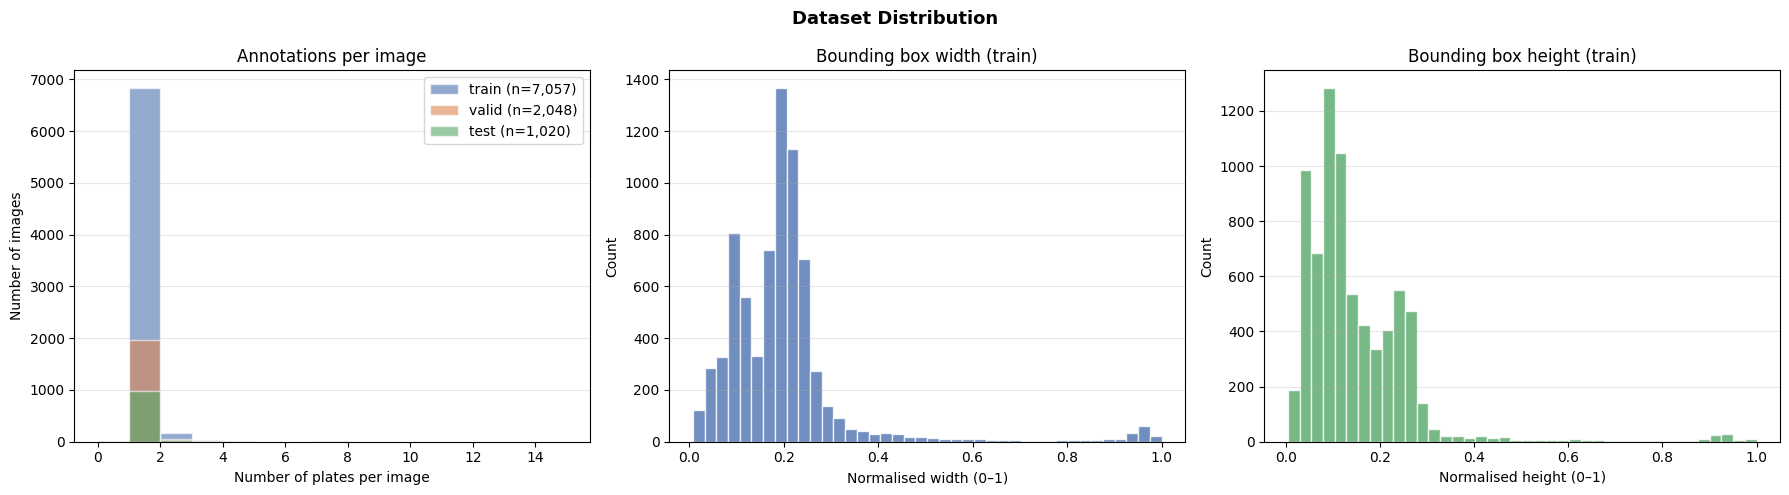


Split      Images    Annotations   Avg plates/img
--------------------------------------------------
train       7,057          7,357             1.04
valid       2,048          2,195             1.07
test        1,020          1,085             1.06


In [32]:
import yaml
import matplotlib.pyplot as plt

with open(DATA_YAML) as f:
    data_cfg = yaml.safe_load(f)

splits = ["train", "valid", "test"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

anns_per_image: dict[str, list[int]] = {}
box_widths: list[float] = []
box_heights: list[float] = []

for split in splits:
    label_dir = ROBOFLOW_DIR / split / "labels"
    if not label_dir.exists():
        continue
    counts = []
    for lbl in label_dir.glob("*.txt"):
        lines = [l for l in lbl.read_text().splitlines() if l.strip()]
        counts.append(len(lines))
        if split == "train":
            for line in lines:
                parts = line.split()
                box_widths.append(float(parts[3]))
                box_heights.append(float(parts[4]))
    anns_per_image[split] = counts

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: annotations per image per split (overlapping histograms)
max_anns = max(max(v) for v in anns_per_image.values() if v)
bins = range(0, max_anns + 2)
for i, split in enumerate(splits):
    if split in anns_per_image:
        axes[0].hist(
            anns_per_image[split],
            bins=bins,
            alpha=0.6,
            color=colors[i],
            label=f"{split} (n={len(anns_per_image[split]):,})",
            edgecolor="white",
        )
axes[0].set_title("Annotations per image")
axes[0].set_xlabel("Number of plates per image")
axes[0].set_ylabel("Number of images")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Middle: bounding box width distribution (train)
axes[1].hist(box_widths, bins=40, color="#4C72B0", edgecolor="white", alpha=0.8)
axes[1].set_title("Bounding box width (train)")
axes[1].set_xlabel("Normalised width (0–1)")
axes[1].set_ylabel("Count")
axes[1].grid(axis="y", alpha=0.3)

# Right: bounding box height distribution (train)
axes[2].hist(box_heights, bins=40, color="#55A868", edgecolor="white", alpha=0.8)
axes[2].set_title("Bounding box height (train)")
axes[2].set_xlabel("Normalised height (0–1)")
axes[2].set_ylabel("Count")
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Dataset Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n{'Split':<8} {'Images':>8} {'Annotations':>14} {'Avg plates/img':>16}")
print("-" * 50)
for split in splits:
    if split in anns_per_image:
        imgs = len(anns_per_image[split])
        anns = sum(anns_per_image[split])
        print(f"{split:<8} {imgs:>8,} {anns:>14,} {anns / imgs:>16.2f}")

In [33]:
MODEL_PATH = MODELS_DIR / MODEL_NAME
if not MODEL_PATH.exists():
    print(f"Model does not exist — downloading to {MODEL_PATH}")
else:
    print(f"Model already exists at {MODEL_PATH} — skipping download.")

Model already exists at c:\Users\leona\source\repos\TP_Final_plates_detection\models\yolo11n.pt — skipping download.


---
## Section 4: Fine-tuning YOLO11

| Parameter | Value | Reason |
|-----------|-------|--------|
| `model`   | yolo11m | Better feature extraction for small objects (plates = ~20px) |
| `epochs`  | 30 | 10 epochs is insufficient for convergence |
| `imgsz`   | 640 | Balanced memory/precision for RTX A4000 |
| `patience` | 15 | Early stopping to prevent overfitting |
| `degrees` | 30 | Vehicles appear at varying angles |
| `flipud`  | 0.5 | No consistent orientation in vehicle images |
| `mosaic`  | 1.0 | Significantly improves detection of small objects |

In [ ]:
from ultralytics import YOLO
from ultralytics.utils.downloads import safe_download

FORCE_RETRAIN = True  # set to True to start a new experiment ignoring existing runs

existing_runs = sorted(
    (RUNS_DIR / "detect").glob("plate_detection_v1*/weights/best.pt"),
    key=lambda p: p.stat().st_mtime,
)

if existing_runs and not FORCE_RETRAIN:
    BEST_WEIGHTS = existing_runs[-1]
    TRAIN_DIR = BEST_WEIGHTS.parent.parent
    print("Existing training run found — skipping training.")
    print(f"  Run      : {TRAIN_DIR}")
    print(f"  Weights  : {BEST_WEIGHTS}")
    print("\nSet FORCE_RETRAIN = True to start a new experiment.")
else:
    MODEL_PATH = MODELS_DIR / MODEL_NAME
    if not MODEL_PATH.exists():
        print(f"Downloading {MODEL_NAME} to {MODELS_DIR}...")
        safe_download(
            url=f"https://github.com/ultralytics/assets/releases/latest/download/{MODEL_NAME}",
            file=MODELS_DIR,
        )
        print(f"Saved to {MODEL_PATH}")
    else:
        print(f"Model already present at {MODEL_PATH}")

    model = YOLO(str(MODEL_PATH))
    results = model.train(
        data=str(DATA_YAML),
        epochs=30,
        imgsz=640,
        batch=-1,
        patience=15,
        device=device,
        cos_lr=True,
        lrf=0.01,
        weight_decay=0.0005,
        warmup_epochs=3,
        cls=0.5,
        degrees=30.0,
        flipud=0.5,
        fliplr=0.5,
        scale=0.5,
        shear=2.0,
        mosaic=1.0,
        mixup=0.1,
        copy_paste=0.1,
        plots=True,
        name="plate_detection_v1",
        project=str(RUNS_DIR / "detect"),
    )

    TRAIN_DIR = Path(results.save_dir)
    BEST_WEIGHTS = TRAIN_DIR / "weights" / "best.pt"
    print(f"\nTraining complete. Results saved to: {TRAIN_DIR}")

Model already present at c:\Users\leona\source\repos\TP_Final_plates_detection\models\yolo11n.pt
New https://pypi.org/project/ultralytics/8.4.61 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.23  Python-3.10.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX A4000 Laptop GPU, 8192MiB)
engine\trainer: task=detect, mode=train, model=c:\Users\leona\source\repos\TP_Final_plates_detection\models\yolo11n.pt, data=c:\Users\leona\source\repos\TP_Final_plates_detection\datasets\roboflow_annotated\data.yaml, epochs=30, time=None, patience=15, batch=-1, imgsz=640, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=c:\Users\leona\source\repos\TP_Final_plates_detection\runs\detect, name=ship_detection_v1, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4

100%|██████████| 5.35M/5.35M [00:00<00:00, 12.0MB/s]


AMP: checks passed 
AutoBatch: Computing optimal batch size for imgsz=640 at 60.0% CUDA memory utilization.
AutoBatch: CUDA:0 (NVIDIA RTX A4000 Laptop GPU) 8.00G total, 0.10G reserved, 0.06G allocated, 7.84G free
      Params      GFLOPs  GPU_mem (GB)  forward (ms) backward (ms)                   input                  output
     2590035       6.441         0.245         44.62         301.9        (1, 3, 640, 640)                    list
     2590035       12.88         0.354         65.68         77.51        (2, 3, 640, 640)                    list
     2590035       25.76         0.612         57.35         73.53        (4, 3, 640, 640)                    list
     2590035       51.52         1.168         43.22         73.04        (8, 3, 640, 640)                    list
     2590035         103         2.263            65         70.61       (16, 3, 640, 640)                    list
AutoBatch: Using batch-size 34 for CUDA:0 4.85G/8.00G (61%) 


train: Scanning C:\Users\leona\source\repos\TP_Final_plates_detection\datasets\roboflow_annotated\train\labels... 7057 images, 5 backgrounds, 0 corrupt: 100%|██████████| 7057/7057 [00:09<00:00, 769.90it/s]


train: New cache created: C:\Users\leona\source\repos\TP_Final_plates_detection\datasets\roboflow_annotated\train\labels.cache


...

      30/30      4.79G     0.9474     0.4185      1.128         20        640: 100%|██████████| 208/208 [00:59<00:00,  3.52it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 31/31 [00:13<00:00,  2.37it/s]

                   all       2048       2195      0.979      0.928      0.963      0.669



30 epochs completed in 0.643 hours.
Optimizer stripped from c:\Users\leona\source\repos\TP_Final_plates_detection\runs\detect\ship_detection_v1\weights\last.pt, 5.5MB
Optimizer stripped from c:\Users\leona\source\repos\TP_Final_plates_detection\runs\detect\ship_detection_v1\weights\best.pt, 5.5MB

Validating c:\Users\leona\source\repos\TP_Final_plates_detection\runs\detect\ship_detection_v1\weights\best.pt...
Ultralytics 8.3.23  Python-3.10.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX A4000 Laptop GPU, 8192MiB)
YOLO11n summary (fused): 238 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 31/31 [00:14<00:00,  2.09it/s]


                   all       2048       2195      0.977      0.928      0.963      0.671
Speed: 0.3ms preprocess, 1.7ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to c:\Users\leona\source\repos\TP_Final_plates_detection\runs\detect\ship_detection_v1

Training complete. Results saved to: c:\Users\leona\source\repos\TP_Final_plates_detection\runs\detect\ship_detection_v1


---
## Section 5: Training Results

Training run: c:\Users\leona\source\repos\TP_Final_plates_detection\runs\detect\plate_detection_v1

confusion_matrix_normalized.png


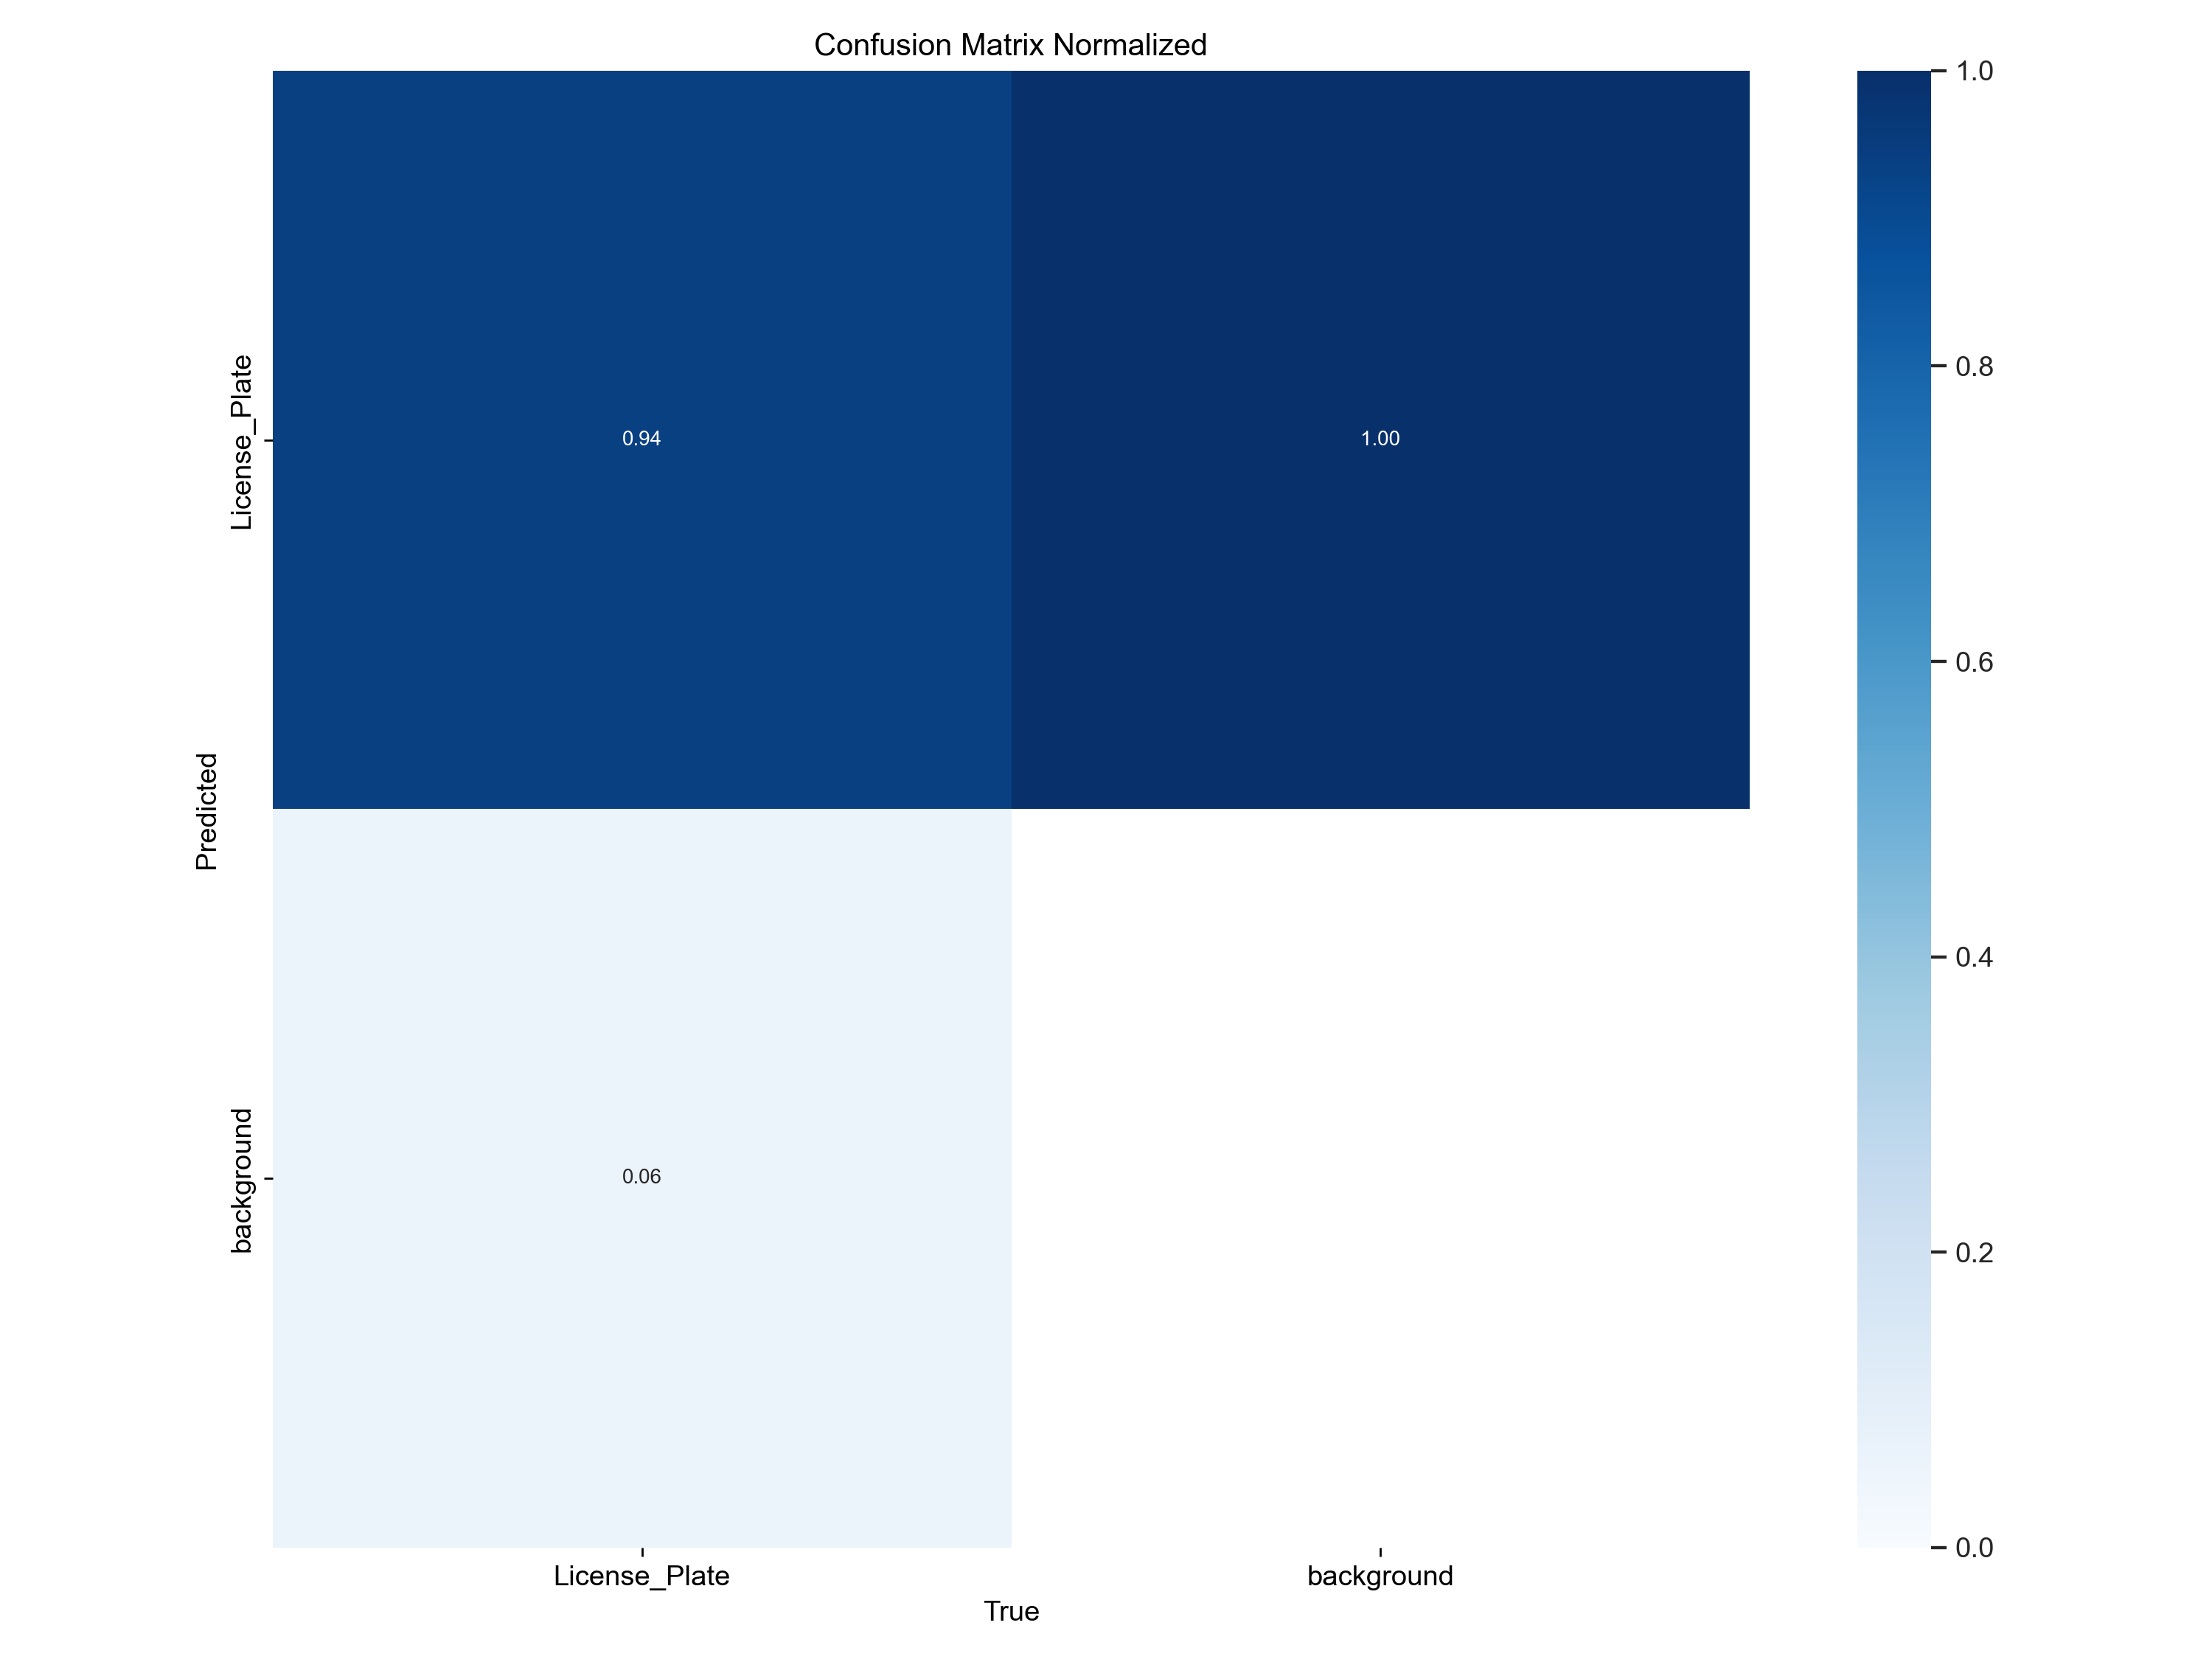


results.png


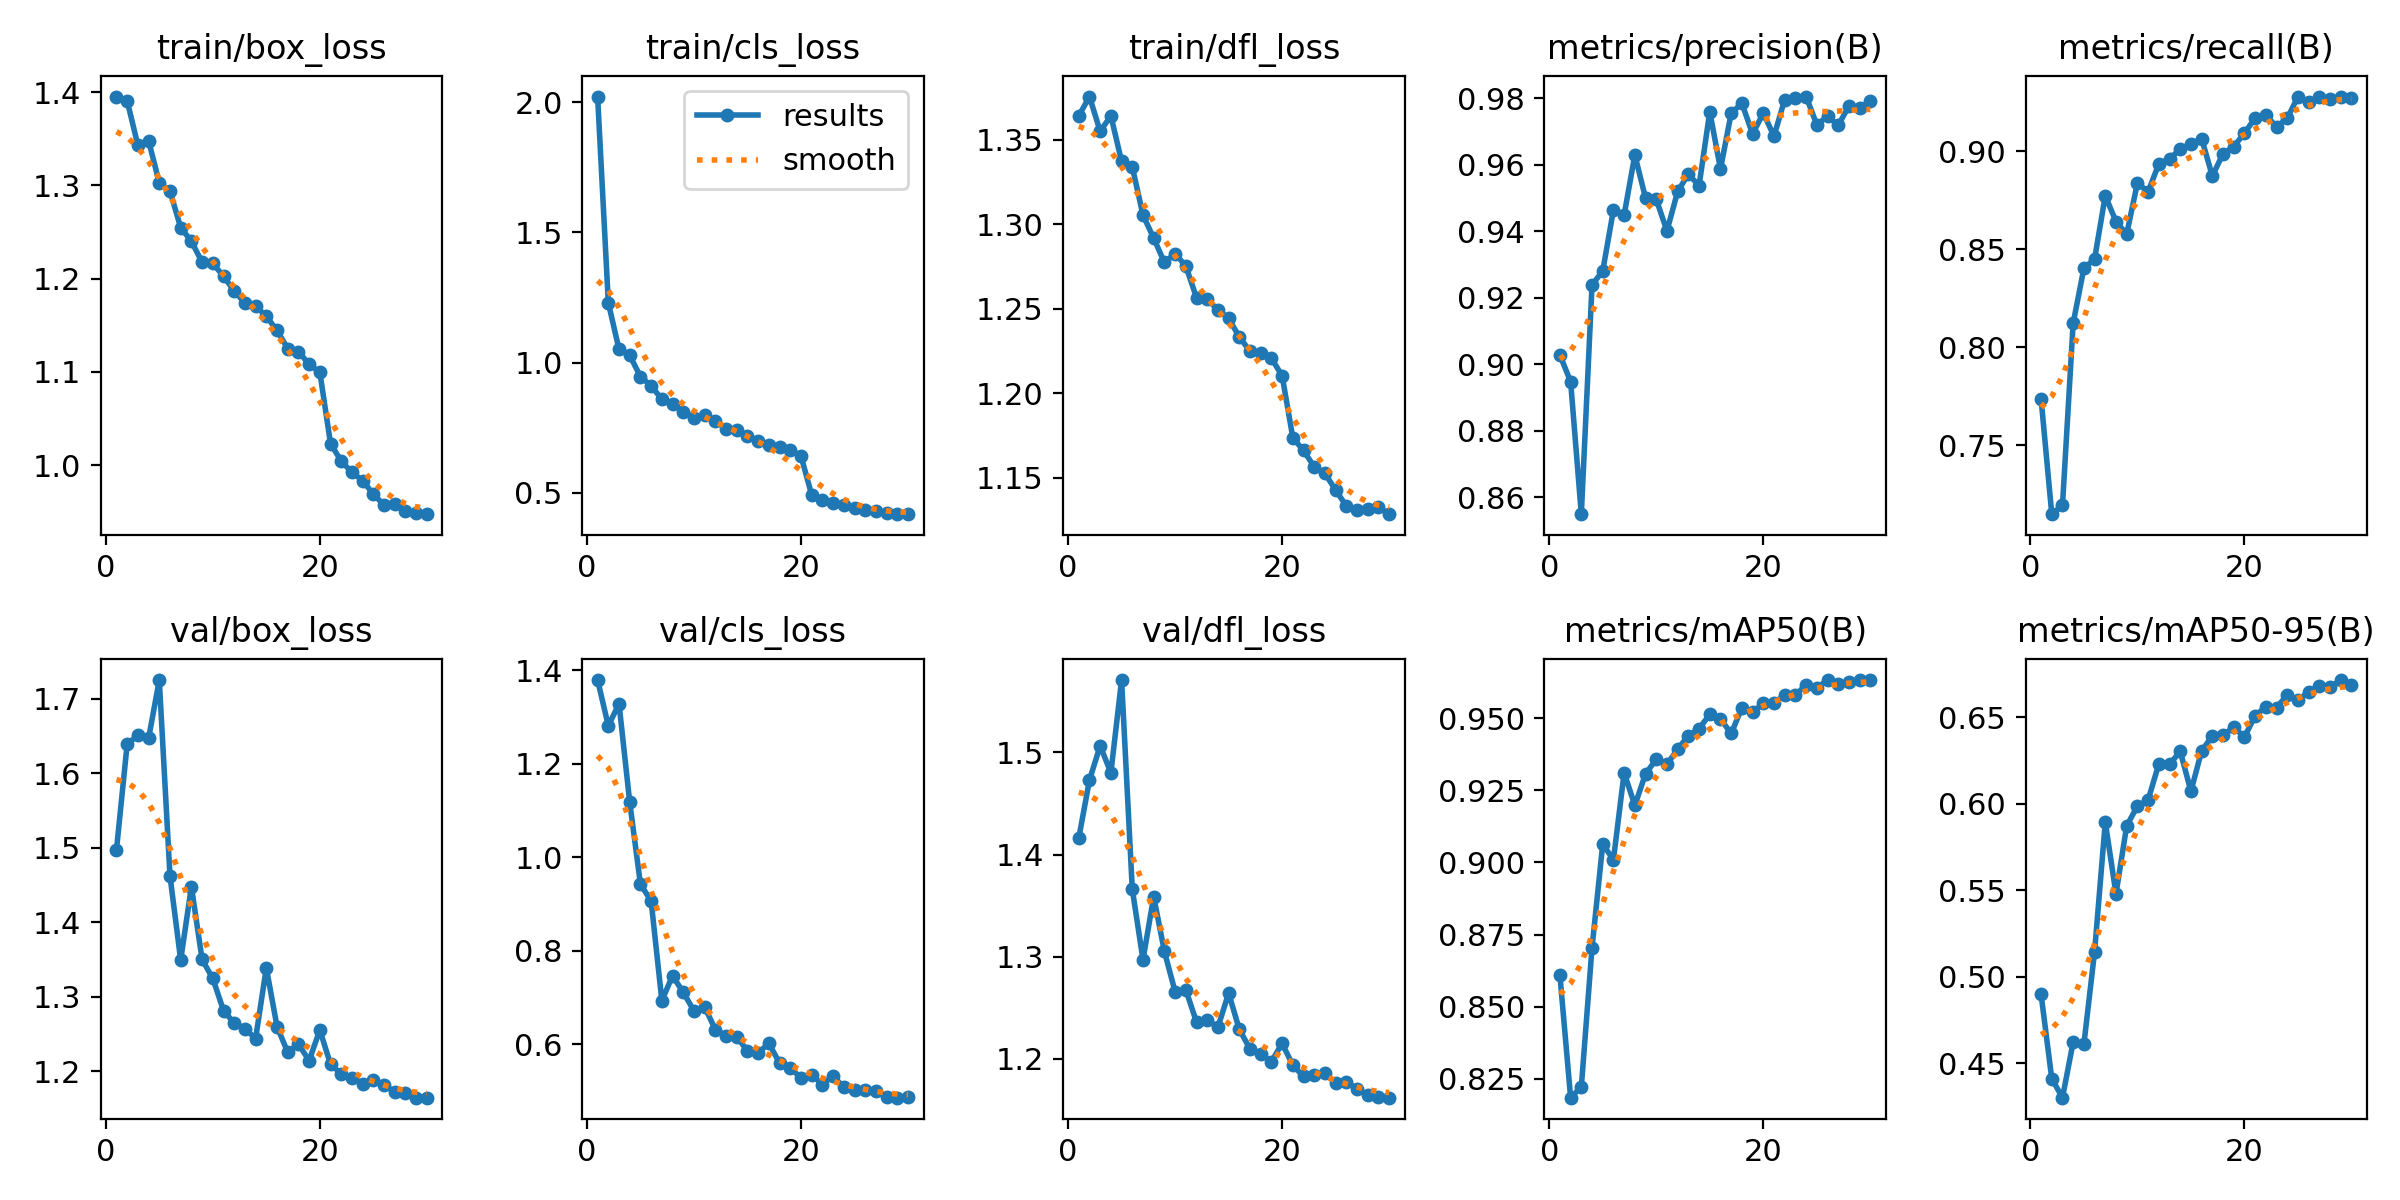


val_batch0_pred.jpg


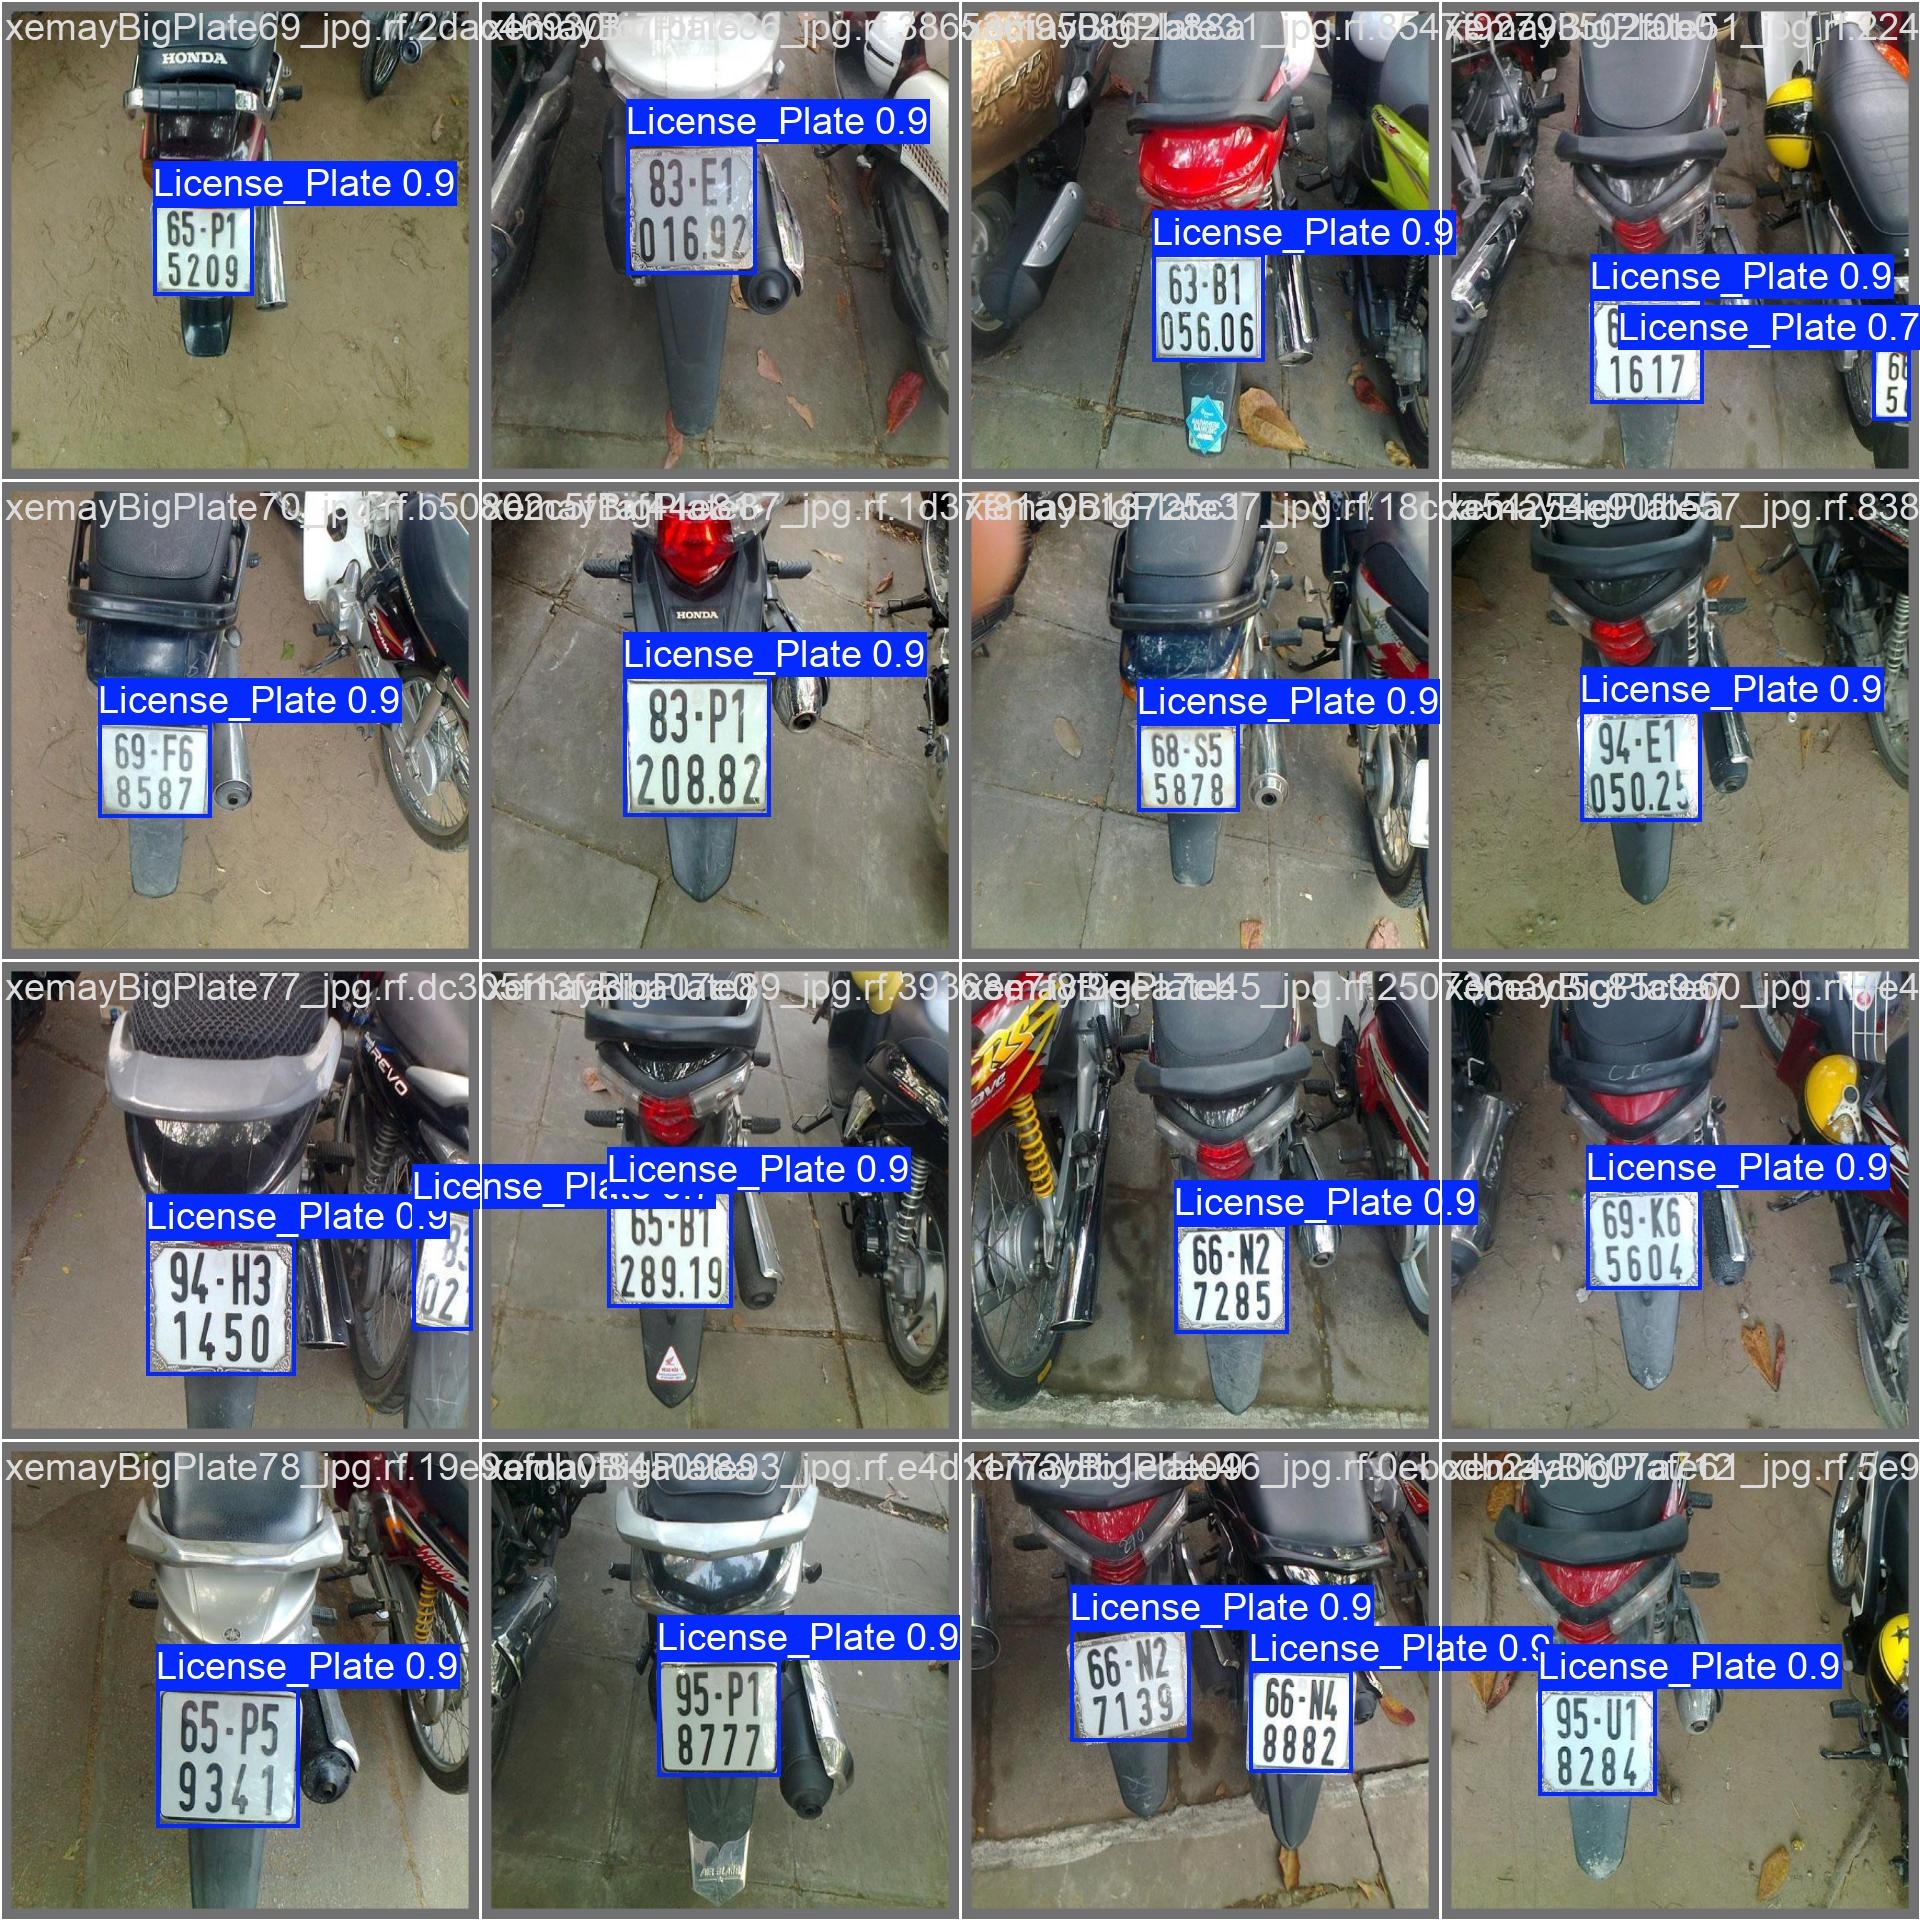

In [12]:
# Resolve latest training run if TRAIN_DIR is not set (re-running this cell after restart)
if "TRAIN_DIR" not in dir() or not Path(TRAIN_DIR).exists():
    train_dirs = sorted(
        RUNS_DIR.glob("detect/plate_detection_v1*/"), key=lambda p: p.stat().st_mtime
    )
    TRAIN_DIR = train_dirs[-1]
    BEST_WEIGHTS = TRAIN_DIR / "weights" / "best.pt"

print(f"Training run: {TRAIN_DIR}")

for filename in ["confusion_matrix_normalized.png", "results.png", "val_batch0_pred.jpg"]:
    path = TRAIN_DIR / filename
    if path.exists():
        print(f"\n{filename}")
        display(IPyImage(filename=str(path), width=800))

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = TRAIN_DIR / "results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

best_epoch = df["metrics/mAP50(B)"].idxmax()
best = df.iloc[best_epoch]

print("Training metrics summary:")
print(f"  Best epoch       : {best_epoch + 1}")
print(f"  mAP@50           : {best.get('metrics/mAP50(B)', 0):.4f}")
print(f"  mAP@50-95        : {best.get('metrics/mAP50-95(B)', 0):.4f}")
print(f"  Precision        : {best.get('metrics/precision(B)', 0):.4f}")
print(f"  Recall           : {best.get('metrics/recall(B)', 0):.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df.index + 1, df["metrics/mAP50(B)"], label="mAP@50")
ax1.plot(df.index + 1, df["metrics/mAP50-95(B)"], label="mAP@50-95")
ax1.axvline(
    best_epoch + 1, color="red", linestyle="--", alpha=0.5, label=f"best (epoch {best_epoch + 1})"
)
ax1.set(title="Detection Metrics per Epoch", xlabel="Epoch", ylabel="mAP")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(df.index + 1, df["train/box_loss"], label="train")
ax2.plot(df.index + 1, df["val/box_loss"], label="val")
ax2.set(title="Box Loss: Train vs Validation", xlabel="Epoch", ylabel="Loss")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Training metrics summary:
  Best epoch       : 30
  mAP@50           : 0.9632
  mAP@50-95        : 0.6686
  Precision        : 0.9792
  Recall           : 0.9276


<Figure size 1400x500 with 2 Axes>

---
## Section 6: Validation

Evaluate the model on the **test set** — data the model never saw during training.

Target metrics for a usable plate detector:
- **mAP@50 > 0.70** — good overall detection quality
- **Recall > Precision** — for traffic enforcement, missing a plate (false negative) is worse than a false alarm

In [14]:
from ultralytics import YOLO

val_model = YOLO(str(BEST_WEIGHTS))
val_results = val_model.val(
    data=str(DATA_YAML),
    split="test",
    conf=0.10,  # lower threshold prioritises recall over precision
    iou=0.5,
)

print(f"\nmAP@50    : {val_results.box.map50:.4f}")
print(f"mAP@50-95 : {val_results.box.map:.4f}")
print(f"Precision : {val_results.box.mp:.4f}")
print(f"Recall    : {val_results.box.mr:.4f}")

Ultralytics 8.3.23  Python-3.10.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX A4000 Laptop GPU, 8192MiB)
YOLO11n summary (fused): 238 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs


val: Scanning C:\Users\leona\source\repos\TP_Final_plates_detection\datasets\roboflow_annotated\test\labels... 1020 images, 1 backgrounds, 0 corrupt: 100%|██████████| 1020/1020 [00:01<00:00, 808.23it/s]


val: New cache created: C:\Users\leona\source\repos\TP_Final_plates_detection\datasets\roboflow_annotated\test\labels.cache


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 64/64 [00:08<00:00,  7.50it/s]


                   all       1020       1085      0.983      0.938      0.973       0.71
Speed: 0.5ms preprocess, 2.9ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to C:\Users\leona\source\repos\diplo-mod-2\runs\detect\val12

mAP@50    : 0.9730
mAP@50-95 : 0.7098
Precision : 0.9826
Recall    : 0.9377


---
## Section 6.1: Save & Export Model

Copy the best weights to `models/` and export to ONNX for CPU inference without PyTorch.

In [29]:
import shutil
from ultralytics import YOLO

# Copy best weights to models/
dest_pt = MODELS_DIR / "plate_detection_best.pt"
shutil.copy(BEST_WEIGHTS, dest_pt)
print(f"Saved weights : {dest_pt}")

# Export to ONNX and move to models/
export_model = YOLO(str(BEST_WEIGHTS))
export_path = Path(export_model.export(format="onnx"))
dest_onnx = MODELS_DIR / "plate_detection.onnx"
shutil.copy(export_path, dest_onnx)
print(f"Exported ONNX : {dest_onnx}")

Saved weights : c:\Users\leona\source\repos\TP_Final_plates_detection\models\plate_detection_best.pt
Ultralytics 8.3.23  Python-3.10.11 torch-2.6.0+cu124 CPU (Intel Xeon W-11855M 3.20GHz)
YOLO11n summary (fused): 238 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs

PyTorch: starting from 'c:\Users\leona\source\repos\TP_Final_plates_detection\runs\detect\plate_detection_v1\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnxslim', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Defaulting to user installation because normal site-packages is not writeable

requirements: AutoUpdate success  2.5s, installed 2 packages: ['onnxslim', 'onnxruntime-gpu']
requirements:  Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 19...
ONNX: simplifier failure: No module named 'onnxslim'
ONNX: export success  4.7s, saved as 'c:\Users\leona\source\

---
## Section 7: Inference with the Fine-tuned Model

In [30]:
from ultralytics import YOLO

test_images_dir = ROBOFLOW_DIR / "test" / "images"
inf_model = YOLO(str(BEST_WEIGHTS))

inf_results = inf_model.predict(
    source=str(test_images_dir),
    conf=0.20,
    iou=0.45,
    save=True,
    name="plate_detection_test",
    project=str(RUNS_DIR / "detect"),
)

predict_dirs = sorted(
    RUNS_DIR.glob("detect/plate_detection_test*/"), key=lambda p: p.stat().st_mtime
)

latest_predict = predict_dirs[-1]
print(f"Predictions saved to: {latest_predict}")



WARNING  inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1020 c:\Users\leona\source\repos\TP_Final_plates_detection\datasets\roboflow_annotated\test\images\0002a5b67e5f0909_jpg.rf.d14df666d2912c80ff347d01730524bb.jpg: 640x640 1 License_Plate, 12.7ms
image 2/1020 c:\Users\leona\source\repos\TP_Final_plates_detection\datasets\roboflow_annotated\test\images\000812dcf304a8e7_jpg.rf.d81590b390e9f69c7181a0b7fabbae8a.jpg: 640x640 1 License_Plate, 17.0ms
image 3/1020 c:\Users\leona\source\repos\TP_Final_plates

Showing 6 sample predictions:


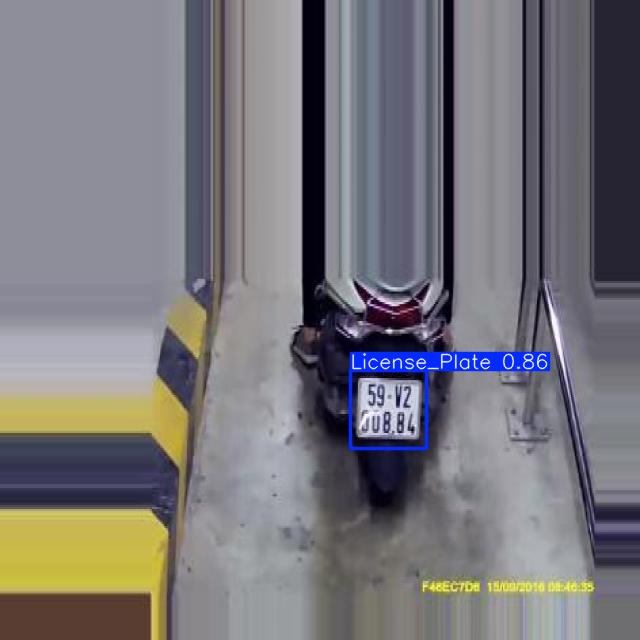

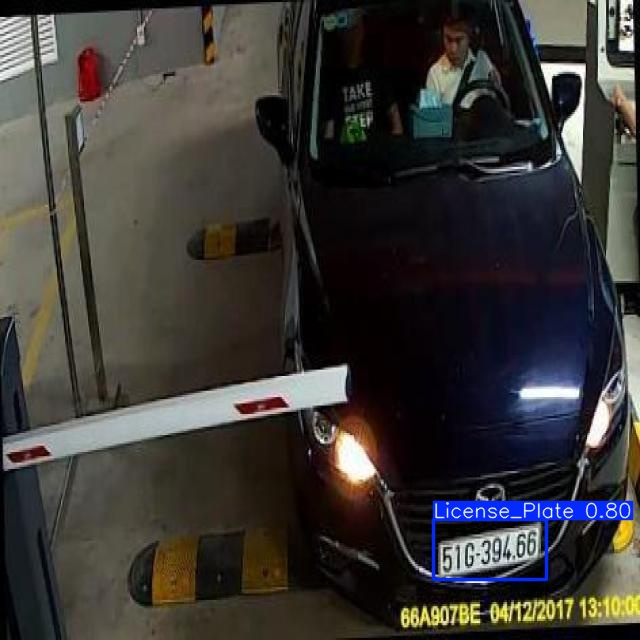

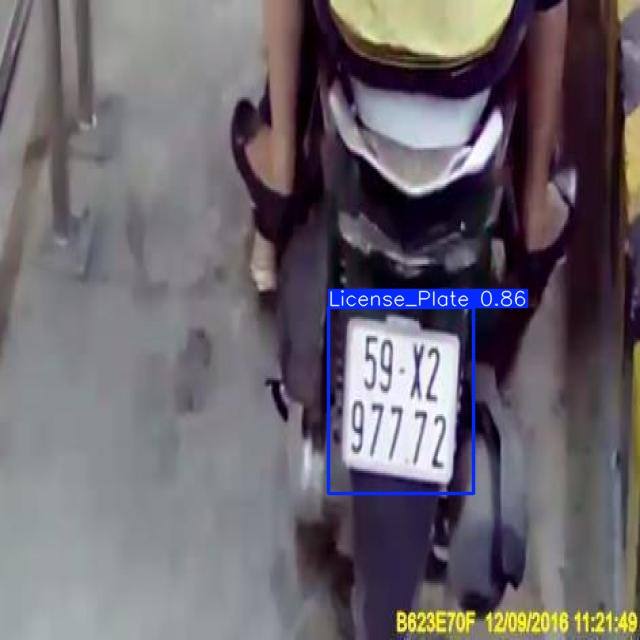

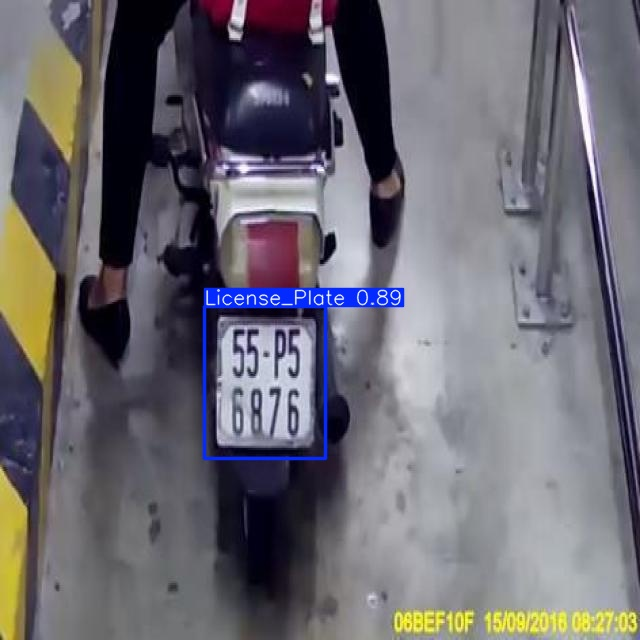

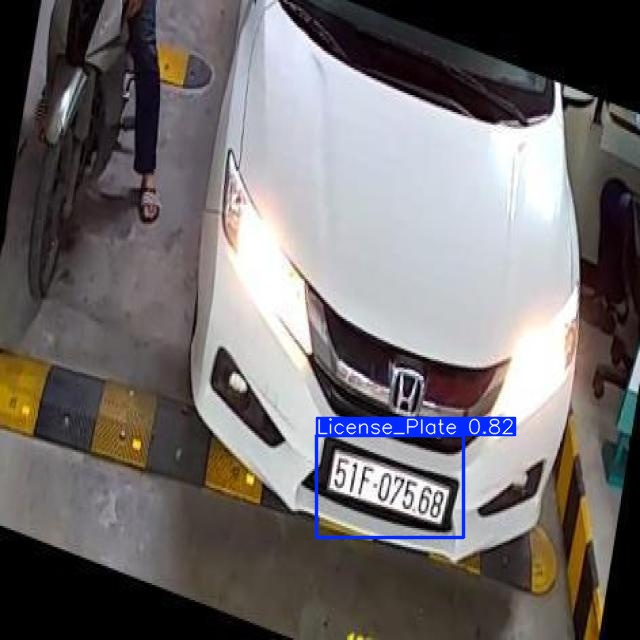

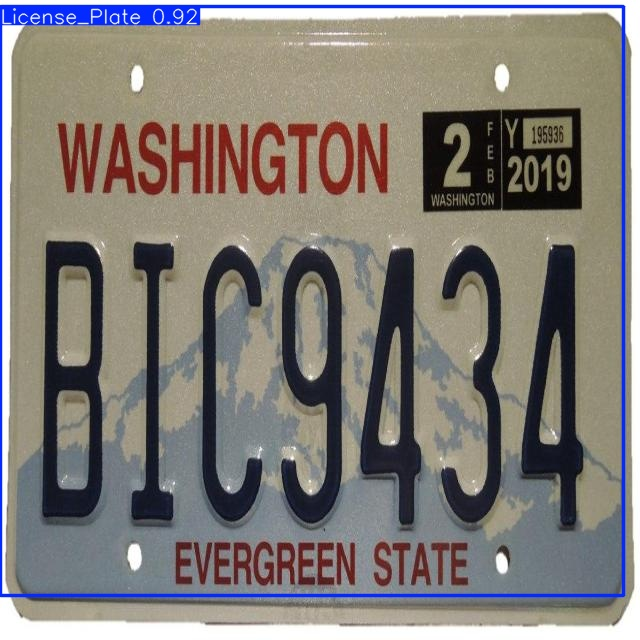

In [16]:
result_images = list(latest_predict.glob("*.jpg")) + list(latest_predict.glob("*.png"))
sample = random.sample(result_images, min(6, len(result_images)))

print(f"Showing {len(sample)} sample predictions:")
for img_path in sample:
    display(IPyImage(filename=str(img_path), width=700))
    print()

Image : auto_1.png
Plates detected: 1
  Plate 1: bbox=(239,216,393,285)  size=155x69px  conf=0.81


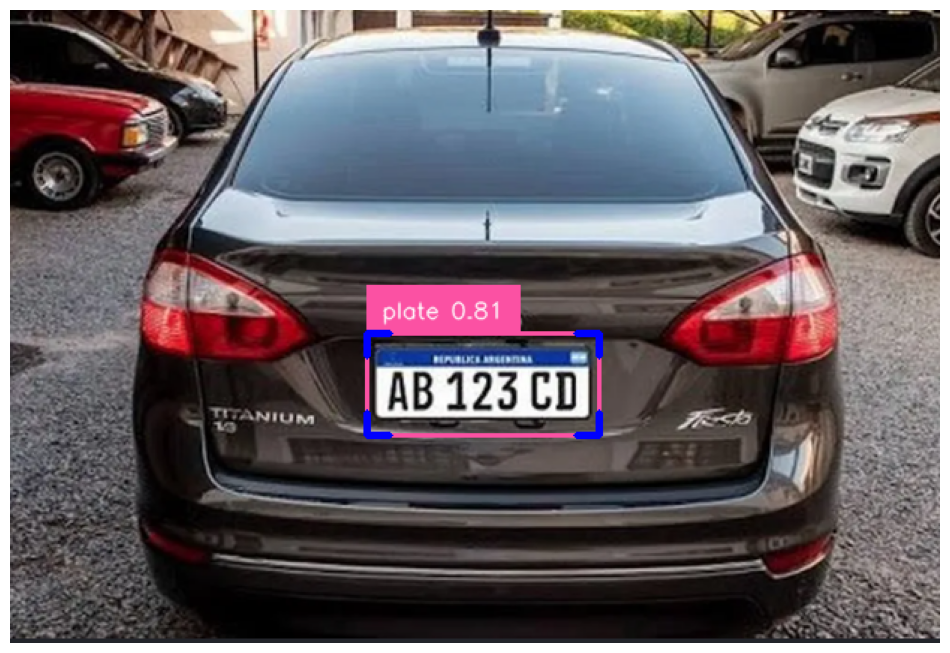

In [27]:
# Programmatic inference with supervision for richer visualisation
from typing import Any

from PIL import Image
import matplotlib.pyplot as plt
import supervision as sv

test_images = list(test_images_dir.glob("*.jpg")) + list(test_images_dir.glob("*.png"))
img_path = ROOT / "images" / "auto_1.png"
image = Image.open(img_path).convert("RGB")

result = inf_model.predict(image, conf=0.25, iou=0.45)[0]
detections = sv.Detections.from_ultralytics(result)

print(f"Image : {img_path.name}")
print(f"Plates detected: {len(detections)}")
assert detections.confidence is not None
for i, (box, conf) in enumerate(zip(detections.xyxy, detections.confidence), start=1):
    x1, y1, x2, y2 = box
    print(
        f"  Plate {i}: bbox=({x1:.0f},{y1:.0f},{x2:.0f},{y2:.0f})  "
        f"size={x2 - x1:.0f}x{y2 - y1:.0f}px  conf={conf:.2f}"
    )

labels = [f"plate {c:.2f}" for c in detections.confidence]
annotated: Any = np.array(image)
annotated = sv.BoxAnnotator(thickness=2).annotate(annotated, detections)
annotated = sv.LabelAnnotator(text_color=sv.Color.WHITE, text_scale=0.5).annotate(
    annotated, detections, labels
)
annotated = sv.BoxCornerAnnotator(color=sv.Color.RED).annotate(annotated, detections)

plt.figure(figsize=(12, 12))
plt.imshow(annotated)
plt.axis("off")
plt.show()

---
## Section 8: Confidence Threshold Analysis

- **Low conf (0.10–0.20):** more detections, more false positives
- **High conf (0.50–0.70):** higher precision, may miss small plates

For traffic enforcement, **recall is prioritised** — missing a plate is worse than a false alarm.
Recommended range: **0.25–0.40**.

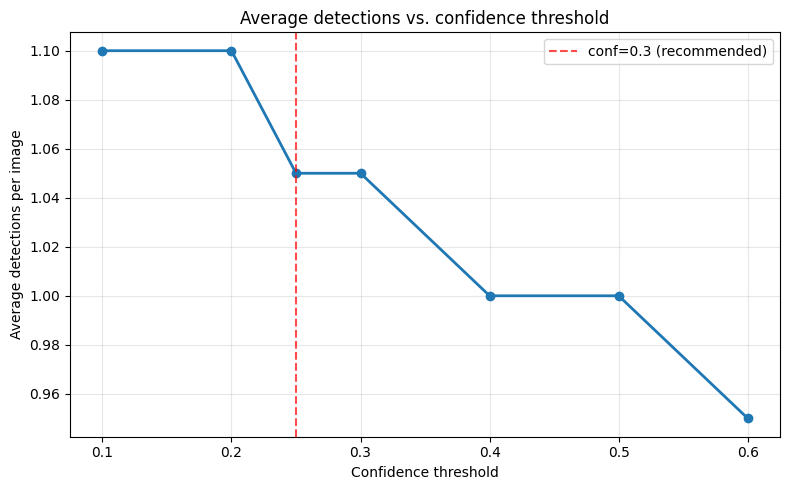

In [25]:
sweep_sample = random.sample(test_images, min(20, len(test_images)))
conf_values = [0.10, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60]
avg_detections = []

for conf in conf_values:
    total = sum(
        len(inf_model.predict(str(p), conf=conf, verbose=False)[0].boxes) for p in sweep_sample
    )
    avg_detections.append(total / len(sweep_sample))

plt.figure(figsize=(8, 5))
plt.plot(conf_values, avg_detections, marker="o", linewidth=2)
plt.axvline(0.25, color="red", linestyle="--", alpha=0.7, label="conf=0.3 (recommended)")
plt.xlabel("Confidence threshold")
plt.ylabel("Average detections per image")
plt.title("Average detections vs. confidence threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Next Steps  BORRAR

- **More annotated data** — the single most effective improvement
- **Higher resolution** — try `imgsz=1280` with `batch=8` for small plates
- **SAHI** — sliced inference for high-resolution images: `pip install sahi`
- **ONNX export** — CPU inference without PyTorch: `model.export(format='onnx')`
- **TensorRT export** — optimised NVIDIA inference: `model.export(format='engine')`
- **Multi-class extension** — add `car_plate`, `truck_plate`, `motorcycle_plate` classes with more annotations

**References:**
- [Ultralytics YOLO11 Docs](https://docs.ultralytics.com)
- [Roboflow Universe — license plate datasets](https://universe.roboflow.com/search?q=license+plate)
- [SAHI for small objects](https://github.com/obss/sahi)